# 09. Evaluate Moment-Guided Deformable DETR

현재 baseline과 Moment-Guided seed 42/43/44 checkpoint를 동일한 VOC2007 validation split에서 직접 재평가합니다. 전체·크기별 AP, 수렴 속도, attention moment geometry, Large evaluator error decomposition을 표와 그래프로 비교합니다. 새 학습은 수행하지 않습니다.

In [1]:
from pathlib import Path
import gc, importlib, json, sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import AutoImageProcessor

ROOT = Path.cwd()
if not (ROOT / 'data').exists() and (Path('D:/gt-super') / 'data').exists():
    ROOT = Path('D:/gt-super')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import gt_aux.config as config_module
import gt_aux.data as data_module
import moment_guided_detr.artifacts as artifacts_module
import moment_guided_detr.evaluate as moment_eval
for module in [config_module, data_module, artifacts_module, moment_eval]:
    importlib.reload(module)

ExperimentConfig = config_module.ExperimentConfig
DataBundle = data_module.DataBundle
VOCDataset = data_module.VOCDataset
collate_detection_batch = data_module.collate_detection_batch
parse_voc_record = data_module.parse_voc_record
print({'root': str(ROOT), 'device': 'cuda' if torch.cuda.is_available() else 'cpu'})

d:\gt-super\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'root': 'd:\\gt-super', 'device': 'cuda'}


## 1. 평가 설정과 고정 validation split

In [2]:
RUN_MODE = 'smoke'
SEEDS = [42, 43, 44]
DATA_SEED = 42
EXPERIMENTS = ['baseline', 'moment_guided']
TRAIN_IMAGES, VAL_IMAGES, EPOCHS = 400, 100, 7
BATCH_SIZE, NUM_WORKERS = 2, 0
IMAGE_MIN_SIZE, IMAGE_MAX_SIZE = 384, 640
RUN_INFERENCE = True
RUN_MOMENT_GEOMETRY = True
RUN_LARGE_DECOMPOSITION = True

CONFIG = ExperimentConfig.for_run(
    ROOT, run_mode=RUN_MODE, seed=SEEDS[0], data_seed=DATA_SEED,
    experiments=EXPERIMENTS, train_images=TRAIN_IMAGES, val_images=VAL_IMAGES,
    epochs=EPOCHS, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
    image_min_size=IMAGE_MIN_SIZE, image_max_size=IMAGE_MAX_SIZE,
)
OUT = artifacts_module.evaluation_dir(CONFIG)
SEED_TAG = '-'.join(map(str, SEEDS))
OVERALL_PATH = OUT / f'overall_metrics_seeds{SEED_TAG}.csv'
SCALE_PATH = OUT / f'scale_metrics_seeds{SEED_TAG}.csv'
PREDICTION_PATH = OUT / f'predictions_seeds{SEED_TAG}.csv'
GEOMETRY_PATH = OUT / f'moment_geometry_seeds{SEED_TAG}.csv'
ERROR_EVENT_PATH = OUT / f'large_error_events_seeds{SEED_TAG}.csv'
ERROR_METRIC_PATH = OUT / f'large_error_metrics_seeds{SEED_TAG}.csv'
PR_PATH = OUT / f'large_pr_seeds{SEED_TAG}.csv'
display(pd.Series(CONFIG.as_dict(), name='value').to_frame())

,value
root,D:\gt-super
run_mode,smoke
checkpoint,SenseTime/deformable-detr
train_images,400
val_images,100
epochs,7
batch_size,2
num_workers,0
image_size,"{'shortest_edge': 384, 'longest_edge': 640}"
lr,0.0002


In [3]:
manifest_path = CONFIG.output_dir / 'voc2007_split_manifest.json'
if not manifest_path.exists():
    raise FileNotFoundError(f'Run 01-2 first or restore split manifest: {manifest_path}')
manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
assert manifest['data_seed'] == DATA_SEED
val_ids = manifest['full_val_ids'][:VAL_IMAGES]
val_records = [parse_voc_record(CONFIG, str(image_id)) for image_id in tqdm(val_ids, desc='VOC val XML')]
try:
    processor = AutoImageProcessor.from_pretrained(CONFIG.checkpoint, local_files_only=True)
except OSError:
    processor = AutoImageProcessor.from_pretrained(CONFIG.checkpoint)
BUNDLE = DataBundle(processor, [], val_records, [], val_records)
collate_fn = lambda batch: collate_detection_batch(batch, BUNDLE.processor, CONFIG)
VAL_LOADER = DataLoader(
    VOCDataset(BUNDLE.val_records, CONFIG, training=False), batch_size=CONFIG.batch_size,
    shuffle=False, num_workers=CONFIG.num_workers, pin_memory=torch.cuda.is_available(),
    collate_fn=collate_fn,
)
print({'val_images': len(val_records), 'val_objects': sum(len(r['boxes_xyxy']) for r in val_records)})

VOC val XML: 100%|██████████| 100/100 [00:00<00:00, 2906.39it/s]

{'val_images': 100, 'val_objects': 311}


## 2. checkpoint 및 history 무결성

baseline은 기존 경로를 그대로 읽고, Moment-Guided는 새 패키지의 별도 경로를 읽습니다.

In [4]:
checkpoint_rows = []
history_frames = []
for seed in SEEDS:
    baseline_checkpoint = CONFIG.checkpoint_path('baseline', seed)
    moment_checkpoint = artifacts_module.checkpoint_path(CONFIG, seed)
    baseline_history = CONFIG.history_path('baseline', seed)
    moment_history = artifacts_module.history_path(CONFIG, seed)
    for experiment, checkpoint, history in [
        ('baseline', baseline_checkpoint, baseline_history),
        ('moment_guided', moment_checkpoint, moment_history),
    ]:
        checkpoint_rows.append({
            'experiment': experiment, 'seed': seed,
            'checkpoint_exists': checkpoint.exists(), 'history_exists': history.exists(),
            'checkpoint_mb': checkpoint.stat().st_size / 1024**2 if checkpoint.exists() else np.nan,
            'checkpoint': str(checkpoint), 'history': str(history),
        })
        if history.exists():
            frame = pd.read_csv(history)
            assert set(frame['data_seed'].dropna().astype(int)) == {DATA_SEED}
            history_frames.append(frame)
checkpoint_df = pd.DataFrame(checkpoint_rows)
display(checkpoint_df)
if not checkpoint_df[['checkpoint_exists', 'history_exists']].all().all():
    raise FileNotFoundError(checkpoint_df.query('not checkpoint_exists or not history_exists')[['experiment', 'seed', 'checkpoint', 'history']].to_dict('records'))
history_df = pd.concat(history_frames, ignore_index=True)
assert set(history_df['experiment']) == set(EXPERIMENTS)

,experiment,seed,checkpoint_exists,history_exists,checkpoint_mb,checkpoint,history
0,baseline,42,True,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...,D:\gt-super\outputs\detr_gt_auxiliary\history_...
1,moment_guided,42,True,True,459.308054,D:\gt-super\cache\checkpoints\checkpoint_smoke...,D:\gt-super\outputs\moment_guided_detr\history...
2,baseline,43,True,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...,D:\gt-super\outputs\detr_gt_auxiliary\history_...
3,moment_guided,43,True,True,459.308115,D:\gt-super\cache\checkpoints\checkpoint_smoke...,D:\gt-super\outputs\moment_guided_detr\history...
4,baseline,44,True,True,460.313863,D:\gt-super\cache\checkpoints\checkpoint_smoke...,D:\gt-super\outputs\detr_gt_auxiliary\history_...
5,moment_guided,44,True,True,459.308054,D:\gt-super\cache\checkpoints\checkpoint_smoke...,D:\gt-super\outputs\moment_guided_detr\history...


## 3. 학습 수렴 속도와 moment loss

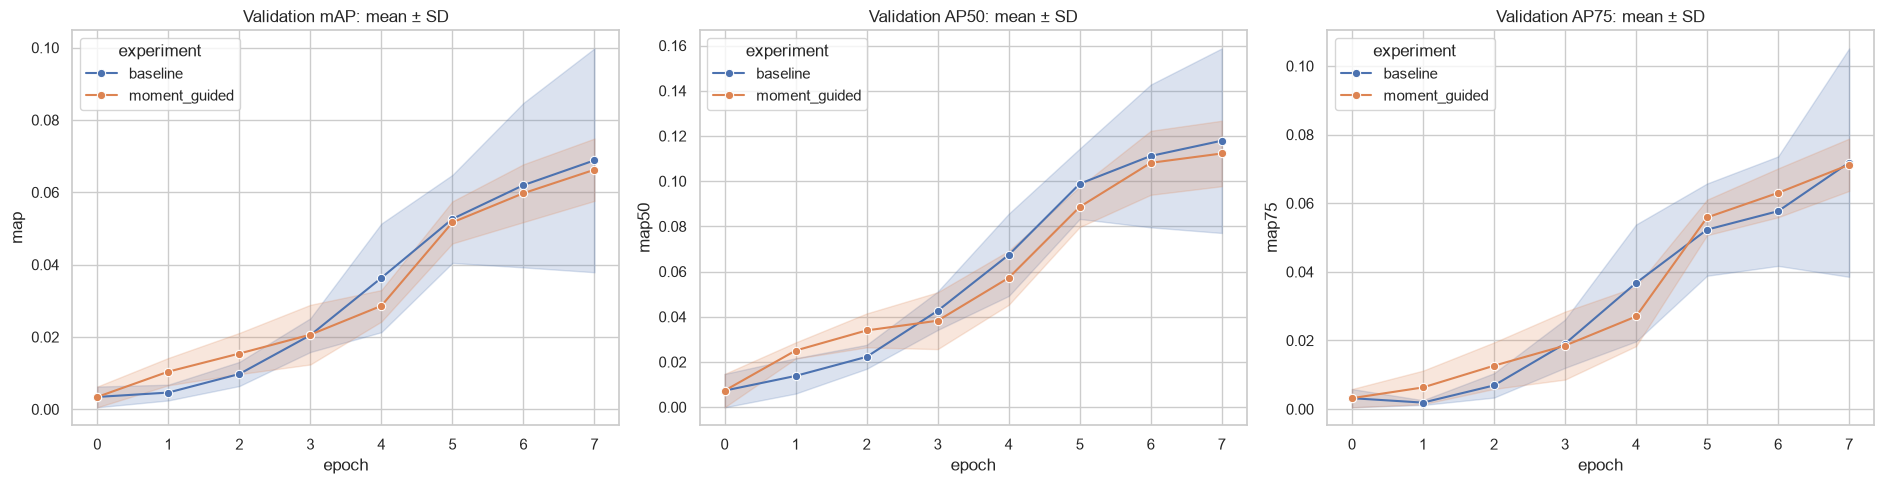

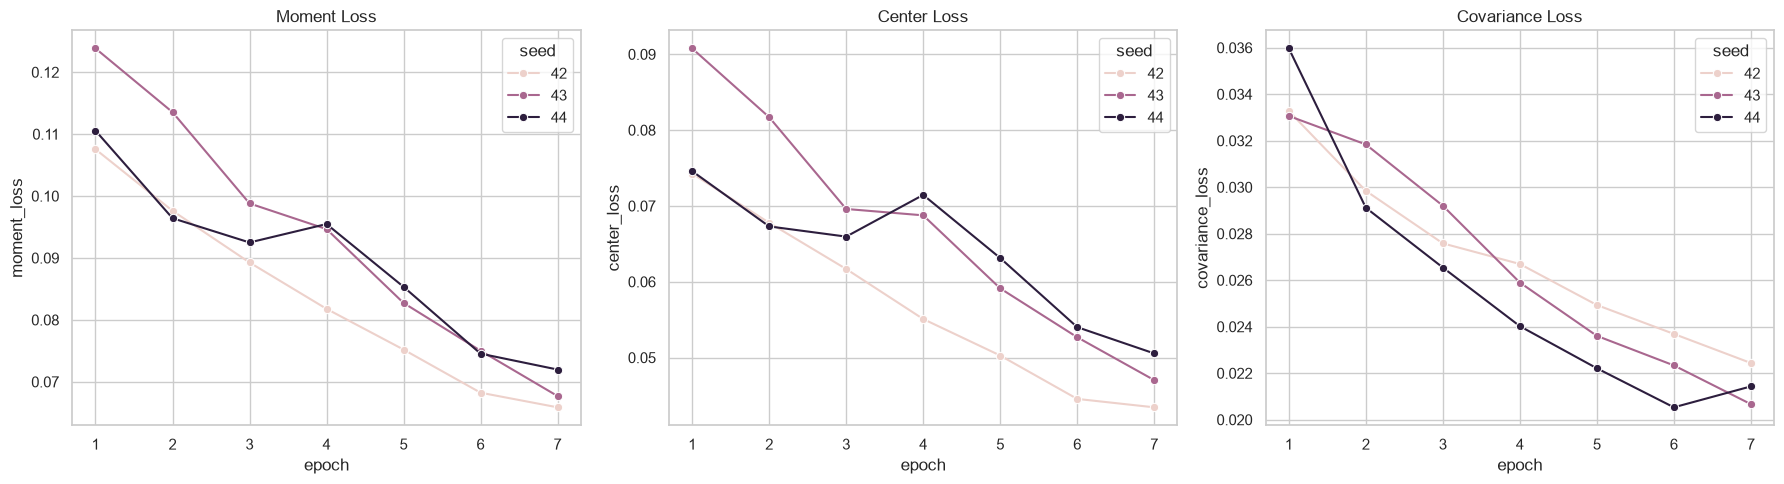

In [5]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
for metric, title, axis in zip(
    ['map', 'map50', 'map75'], ['mAP', 'AP50', 'AP75'], axes,
):
    sns.lineplot(data=history_df, x='epoch', y=metric, hue='experiment',
                 estimator='mean', errorbar='sd', marker='o', ax=axis)
    axis.set_title(f'Validation {title}: mean ± SD')
plt.tight_layout()
convergence_figure = OUT / 'convergence.png'
fig.savefig(convergence_figure, dpi=180, bbox_inches='tight')
plt.show()

moment_history = history_df.query("experiment == 'moment_guided' and epoch > 0")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for metric, axis in zip(['moment_loss', 'center_loss', 'covariance_loss'], axes):
    sns.lineplot(data=moment_history, x='epoch', y=metric, hue='seed', marker='o', ax=axis)
    axis.set_title(metric.replace('_', ' ').title())
plt.tight_layout()
moment_loss_figure = OUT / 'moment_loss_curves.png'
fig.savefig(moment_loss_figure, dpi=180, bbox_inches='tight')
plt.show()

In [6]:
auc_rows = []
for (experiment, seed), frame in history_df.groupby(['experiment', 'seed']):
    frame = frame.sort_values('epoch')
    auc_rows.append({
        'experiment': experiment, 'seed': seed,
        'mAP_epoch_auc': float(np.trapezoid(frame['map'], frame['epoch']) / max(frame['epoch'].max(), 1)),
        'best_mAP': float(frame['map'].max()),
        'final_mAP_history': float(frame.iloc[-1]['map']),
    })
auc_df = pd.DataFrame(auc_rows)
baseline_auc = auc_df.query("experiment == 'baseline'").drop(columns='experiment').rename(columns={c: f'baseline_{c}' for c in ['mAP_epoch_auc', 'best_mAP', 'final_mAP_history']})
auc_delta = auc_df.query("experiment == 'moment_guided'").merge(baseline_auc, on='seed')
for metric in ['mAP_epoch_auc', 'best_mAP', 'final_mAP_history']:
    auc_delta[f'delta_{metric}'] = auc_delta[metric] - auc_delta[f'baseline_{metric}']
display(auc_delta.style.format({c: '{:+.4f}' for c in auc_delta.columns if c.startswith('delta_')}))

,experiment,seed,mAP_epoch_auc,best_mAP,final_mAP_history,baseline_mAP_epoch_auc,baseline_best_mAP,baseline_final_mAP_history,delta_mAP_epoch_auc,delta_best_mAP,delta_final_mAP_history
0,moment_guided,42,0.032308,0.069544,0.069544,0.027408,0.059872,0.059872,+0.0049,+0.0097,+0.0097
1,moment_guided,43,0.028902,0.056465,0.056465,0.043230,0.103289,0.103289,-0.0143,-0.0468,-0.0468
2,moment_guided,44,0.033637,0.072732,0.072732,0.024485,0.043373,0.043373,+0.0092,+0.0294,+0.0294


## 4. 현재 checkpoint 직접 재평가

history의 과거 값이나 기존 comprehensive cache를 재사용하지 않고, 두 모델의 현재 checkpoint를 동일 loader로 다시 추론합니다.

In [7]:
if RUN_INFERENCE:
    overall_rows, scale_rows, prediction_rows = [], [], []
    for seed in SEEDS:
        for experiment in EXPERIMENTS:
            overall, scales, predictions = moment_eval.collect_evaluation_run(
                CONFIG, BUNDLE, VAL_LOADER, experiment, seed,
            )
            overall_rows.append(overall)
            scale_rows.extend(scales)
            prediction_rows.extend(predictions)
    overall_df = pd.DataFrame(overall_rows)
    scale_df = pd.DataFrame(scale_rows)
    prediction_df = pd.DataFrame(prediction_rows)
    overall_df.to_csv(OVERALL_PATH, index=False)
    scale_df.to_csv(SCALE_PATH, index=False)
    prediction_df.to_csv(PREDICTION_PATH, index=False)
else:
    overall_df = pd.read_csv(OVERALL_PATH)
    scale_df = pd.read_csv(SCALE_PATH)
    prediction_df = pd.read_csv(PREDICTION_PATH)
display(overall_df.style.format({c: '{:.4f}' for c in ['mAP', 'AP50', 'AP75', 'AR100']}))
print('Saved/loaded:', OVERALL_PATH, SCALE_PATH, PREDICTION_PATH)

Loading weights: 100%|██████████| 545/545 [00:00<00:00, 7847.28it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mode

,experiment,seed,checkpoint_epoch,fingerprint,mAP,AP50,AP75,AR100,inference_seconds
0,baseline,42,7,dc32a3f95dff47eb,0.0599,0.1102,0.0593,0.3915,5.785433
1,moment_guided,42,7,c7ca6dae43b5cc30,0.0695,0.1220,0.0725,0.3857,4.937091
2,baseline,43,7,70d36536e9f39633,0.1033,0.1620,0.1096,0.4377,4.787376
3,moment_guided,43,7,77cc5d9c2d1444b5,0.0565,0.0956,0.0630,0.3601,4.727182
4,baseline,44,7,1e6f4a59877d8f17,0.0434,0.0815,0.0467,0.3347,4.874685
5,moment_guided,44,7,d2ab171ba43ef6b8,0.0727,0.1192,0.0781,0.4003,4.861325


Saved/loaded: D:\gt-super\outputs\moment_guided_detr\evaluation\overall_metrics_seeds42-43-44.csv D:\gt-super\outputs\moment_guided_detr\evaluation\scale_metrics_seeds42-43-44.csv D:\gt-super\outputs\moment_guided_detr\evaluation\predictions_seeds42-43-44.csv


## 5. 전체 성능: 평균±표준편차와 paired seed delta

,seed,delta_mAP,delta_AP50,delta_AP75,delta_AR100
0,42,+0.0097,+0.0118,+0.0132,-0.0058
1,43,-0.0468,-0.0665,-0.0466,-0.0776
2,44,+0.0294,+0.0377,+0.0314,+0.0656


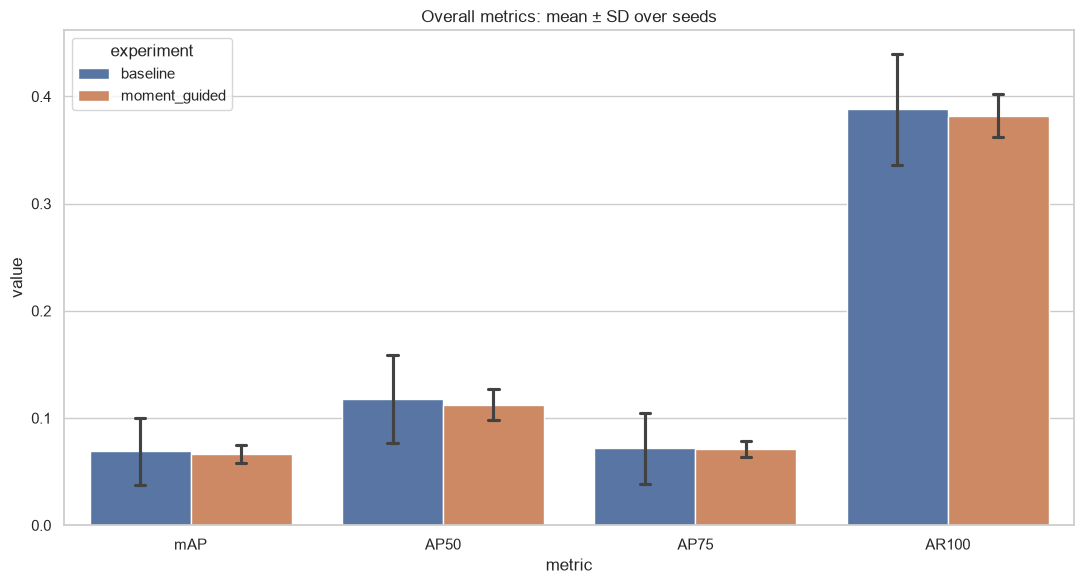

In [8]:
OVERALL_METRICS = ['mAP', 'AP50', 'AP75', 'AR100']
overall_summary = overall_df.groupby('experiment')[OVERALL_METRICS].agg(['mean', 'std'])
display(overall_summary.style.format('{:.4f}'))
baseline_overall = overall_df.query("experiment == 'baseline'")[['seed'] + OVERALL_METRICS].rename(columns={m: f'baseline_{m}' for m in OVERALL_METRICS})
overall_delta = overall_df.query("experiment == 'moment_guided'").merge(baseline_overall, on='seed')
for metric in OVERALL_METRICS:
    overall_delta[f'delta_{metric}'] = overall_delta[metric] - overall_delta[f'baseline_{metric}']
display(overall_delta[['seed'] + [f'delta_{m}' for m in OVERALL_METRICS]].style.format({f'delta_{m}': '{:+.4f}' for m in OVERALL_METRICS}))

plot_df = overall_df.melt(id_vars=['experiment', 'seed'], value_vars=OVERALL_METRICS, var_name='metric', value_name='value')
fig, axis = plt.subplots(figsize=(11, 6))
sns.barplot(data=plot_df, x='metric', y='value', hue='experiment', estimator='mean', errorbar='sd', capsize=.08, ax=axis)
axis.set_title('Overall metrics: mean ± SD over seeds')
plt.tight_layout()
fig.savefig(OUT / 'overall_metrics.png', dpi=180, bbox_inches='tight')
plt.show()

## 6. Small / Medium / Large AP·AP50·AP75·AR

,seed,scale,delta_AP,delta_AP50,delta_AP75,delta_AR
0,42,small,+0.0303,+0.0856,+0.0200,+0.0466
1,42,medium,+0.0311,+0.0117,+0.0525,-0.0198
2,42,large,+0.0038,+0.0090,+0.0028,-0.0237
3,43,small,-0.0255,-0.0670,-0.0270,-0.0096
4,43,medium,-0.0346,-0.0887,-0.0211,-0.0180
5,43,large,-0.0771,-0.0933,-0.0945,-0.1421
6,44,small,+0.0087,+0.0437,+0.0015,+0.0105
7,44,medium,+0.0451,+0.0761,+0.0456,+0.0389
8,44,large,+0.0056,+0.0024,+0.0061,+0.0834


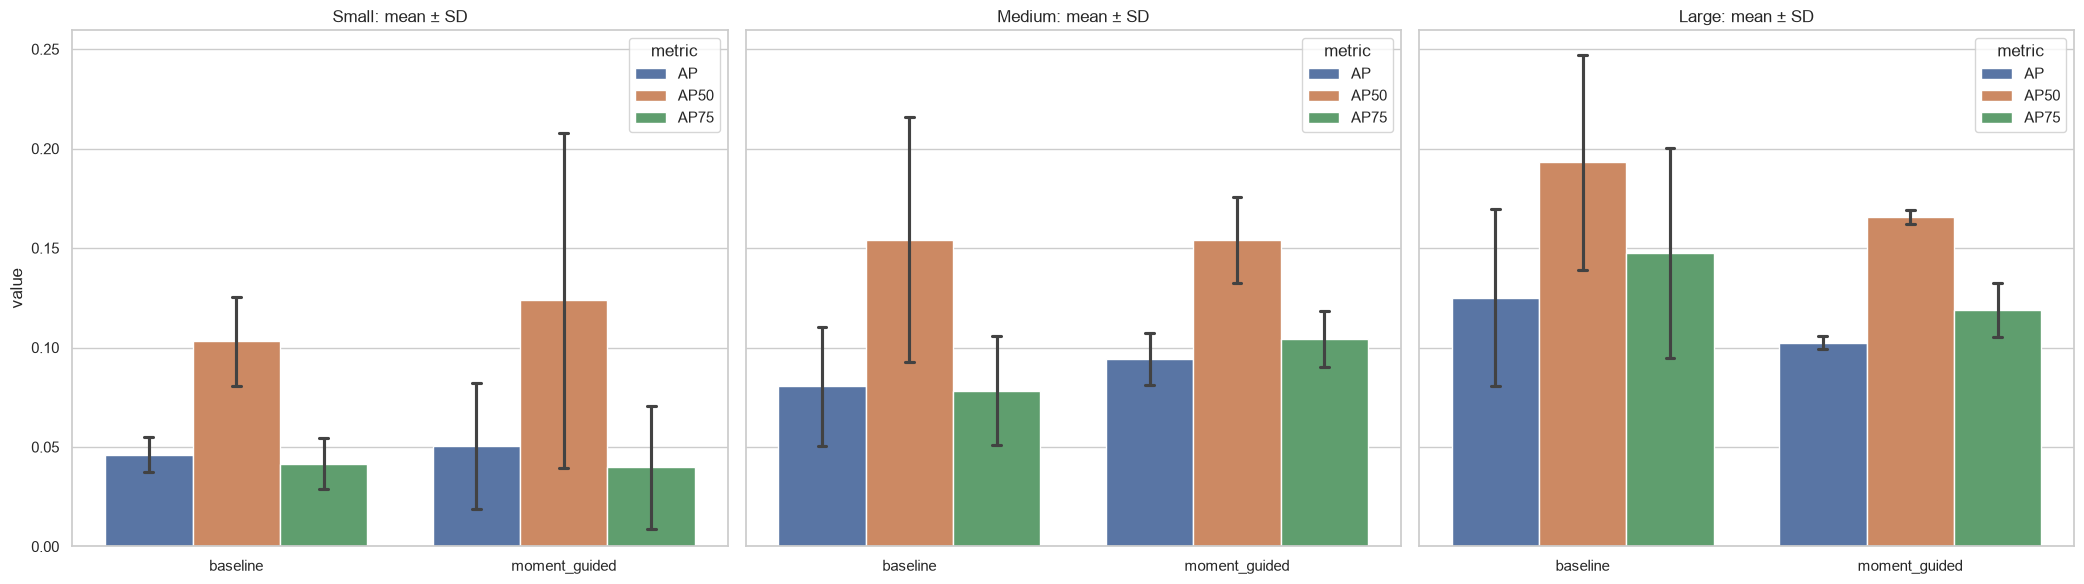

In [9]:
SCALE_METRICS = ['AP', 'AP50', 'AP75', 'AR']
scale_summary = scale_df.groupby(['scale', 'experiment'])[SCALE_METRICS].agg(['mean', 'std'])
display(scale_summary.style.format('{:.4f}'))
baseline_scale = scale_df.query("experiment == 'baseline'")[['seed', 'scale'] + SCALE_METRICS].rename(columns={m: f'baseline_{m}' for m in SCALE_METRICS})
scale_delta = scale_df.query("experiment == 'moment_guided'").merge(baseline_scale, on=['seed', 'scale'])
for metric in SCALE_METRICS:
    scale_delta[f'delta_{metric}'] = scale_delta[metric] - scale_delta[f'baseline_{metric}']
display(scale_delta[['seed', 'scale'] + [f'delta_{m}' for m in SCALE_METRICS]].style.format({f'delta_{m}': '{:+.4f}' for m in SCALE_METRICS}))

scale_plot = scale_df.melt(id_vars=['experiment', 'seed', 'scale'], value_vars=['AP', 'AP50', 'AP75'], var_name='metric', value_name='value')
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
for axis, scale in zip(axes, ['small', 'medium', 'large']):
    sns.barplot(data=scale_plot.query('scale == @scale'), x='experiment', y='value', hue='metric', estimator='mean', errorbar='sd', capsize=.08, ax=axis)
    axis.set_title(f'{scale.capitalize()}: mean ± SD')
    axis.set_xlabel('')
plt.tight_layout()
fig.savefig(OUT / 'scale_metrics.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. 실제 attention moment geometry

Baseline과 Moment-Guided checkpoint의 matched query에 대해 동일한 방식으로 center error, covariance error, predicted/target variance를 S/M/L별로 측정합니다. 모델은 eval mode이며 가중치는 변경하지 않습니다.

Loading weights: 100%|██████████| 545/545 [00:00<00:00, 14113.43it/s]
[transformers] DeformableDetrForObjectDetection LOAD REPORT from: SenseTime/deformable-detr
Key                                                            | Status     |                                                                                         
---------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                         
mod

,seed,scale,delta_center_error_l1,delta_covariance_error_l1,delta_valid_attention_mass,delta_off_diagonal_abs
0,42,large,-0.02416,-0.01701,+0.07138,+0.00004
1,42,medium,-0.02795,-0.00646,+0.10753,-0.00218
2,42,small,-0.01144,-0.00324,+0.09940,-0.00138
3,43,large,-0.01000,-0.01779,+0.04551,+0.00080
4,43,medium,-0.01550,-0.00192,+0.09008,-0.00080
5,43,small,-0.03098,-0.00324,+0.08140,-0.00125
6,44,large,-0.02583,-0.01526,-0.03567,-0.00018
7,44,medium,-0.00267,-0.00196,-0.02087,-0.00089
8,44,small,+0.00177,-0.00138,-0.01059,-0.00044


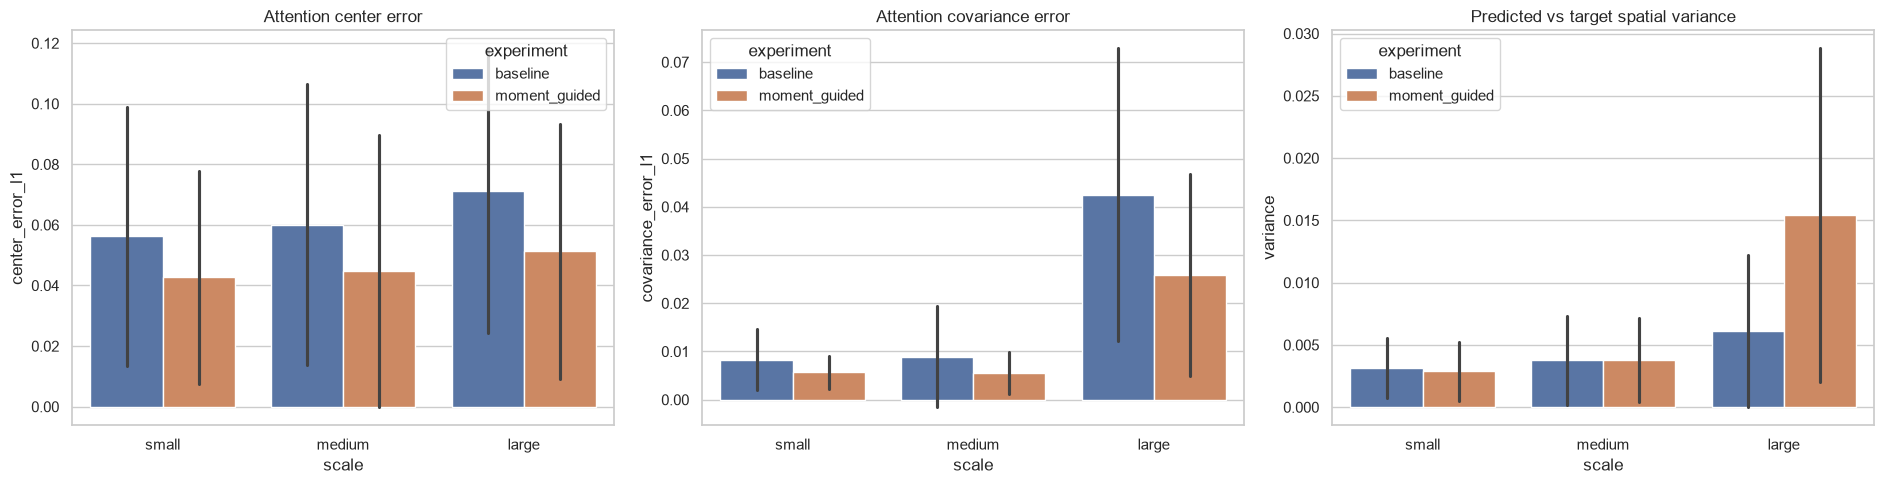

Saved/loaded: D:\gt-super\outputs\moment_guided_detr\evaluation\moment_geometry_seeds42-43-44.csv


In [10]:
if RUN_MOMENT_GEOMETRY:
    geometry_rows = []
    for seed in SEEDS:
        for experiment in EXPERIMENTS:
            geometry_rows.extend(moment_eval.collect_attention_geometry(CONFIG, BUNDLE, VAL_LOADER, experiment, seed))
    geometry_df = pd.DataFrame(geometry_rows)
    geometry_df.to_csv(GEOMETRY_PATH, index=False)
else:
    geometry_df = pd.read_csv(GEOMETRY_PATH)
GEOMETRY_METRICS = ['center_error_l1', 'covariance_error_l1', 'valid_attention_mass', 'off_diagonal_abs']
geometry_summary = geometry_df.groupby(['scale', 'experiment'])[GEOMETRY_METRICS].agg(['mean', 'std', 'count'])
display(geometry_summary.style.format('{:.5f}'))
baseline_geometry = geometry_df.query("experiment == 'baseline'").groupby(['seed', 'scale'])[GEOMETRY_METRICS].mean().reset_index().rename(columns={m: f'baseline_{m}' for m in GEOMETRY_METRICS})
geometry_delta = geometry_df.query("experiment == 'moment_guided'").groupby(['seed', 'scale'])[GEOMETRY_METRICS].mean().reset_index().merge(baseline_geometry, on=['seed', 'scale'])
for metric in GEOMETRY_METRICS:
    geometry_delta[f'delta_{metric}'] = geometry_delta[metric] - geometry_delta[f'baseline_{metric}']
display(geometry_delta[['seed', 'scale'] + [f'delta_{m}' for m in GEOMETRY_METRICS]].style.format({f'delta_{m}': '{:+.5f}' for m in GEOMETRY_METRICS}))

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sns.barplot(data=geometry_df, x='scale', y='center_error_l1', hue='experiment', order=['small', 'medium', 'large'], errorbar='sd', ax=axes[0])
axes[0].set_title('Attention center error')
sns.barplot(data=geometry_df, x='scale', y='covariance_error_l1', hue='experiment', order=['small', 'medium', 'large'], errorbar='sd', ax=axes[1])
axes[1].set_title('Attention covariance error')
variance_df = pd.concat([
    geometry_df[['experiment', 'scale', 'predicted_var_x', 'predicted_var_y']].rename(columns={'predicted_var_x': 'x', 'predicted_var_y': 'y'}).assign(kind='predicted'),
    geometry_df[['experiment', 'scale', 'target_var_x', 'target_var_y']].rename(columns={'target_var_x': 'x', 'target_var_y': 'y'}).assign(kind='target'),
]).melt(id_vars=['experiment', 'scale', 'kind'], value_vars=['x', 'y'], var_name='axis', value_name='variance')
predicted_variance_df = variance_df.query("kind == 'predicted'")
sns.barplot(data=predicted_variance_df, x='scale', y='variance', hue='experiment', order=['small', 'medium', 'large'], errorbar='sd', ax=axes[2])
axes[2].set_title('Predicted vs target spatial variance')
plt.tight_layout()
fig.savefig(OUT / 'moment_geometry.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved/loaded:', GEOMETRY_PATH)

## 8. Evaluator-level Large error decomposition과 PR curve

COCO evaluator의 score-order greedy matching 결과를 IoU 0.50/0.75에서 TP, Duplicate/Localization/Classification/Background FP, Missed GT로 분해합니다.

,experiment,seed,iou_threshold,TP,Duplicate FP,Localization FP,Classification FP,Background FP,Missed GT,Precision_micro,Recall_micro,Recall_COCO_macro,AP_L
0,baseline,42,0.50,156,1610,550,4425,1133,34,0.019812,0.821053,0.655150,0.159737
1,baseline,42,0.75,129,765,1454,3215,2311,61,0.016383,0.678947,0.541816,0.106680
2,baseline,43,0.50,171,1217,463,4951,1022,19,0.021856,0.900000,0.810467,0.255451
3,baseline,43,0.75,144,437,1319,3140,2784,46,0.018405,0.757895,0.654920,0.207304
4,baseline,44,0.50,141,1627,531,4000,966,49,0.019408,0.742105,0.562066,0.164248
5,baseline,44,0.75,119,714,1491,2532,2412,71,0.016373,0.626316,0.468027,0.128582
6,moment_guided,42,0.50,159,1462,575,4407,1060,31,0.020749,0.836842,0.678697,0.168740
7,moment_guided,42,0.75,130,603,1508,2819,2602,60,0.016967,0.684211,0.501191,0.109554
8,moment_guided,43,0.50,154,1494,416,4319,1061,36,0.020688,0.810526,0.636822,0.162157
9,moment_guided,43,0.75,128,677,1292,2758,2592,62,0.017188,0.673684,0.472958,0.112872


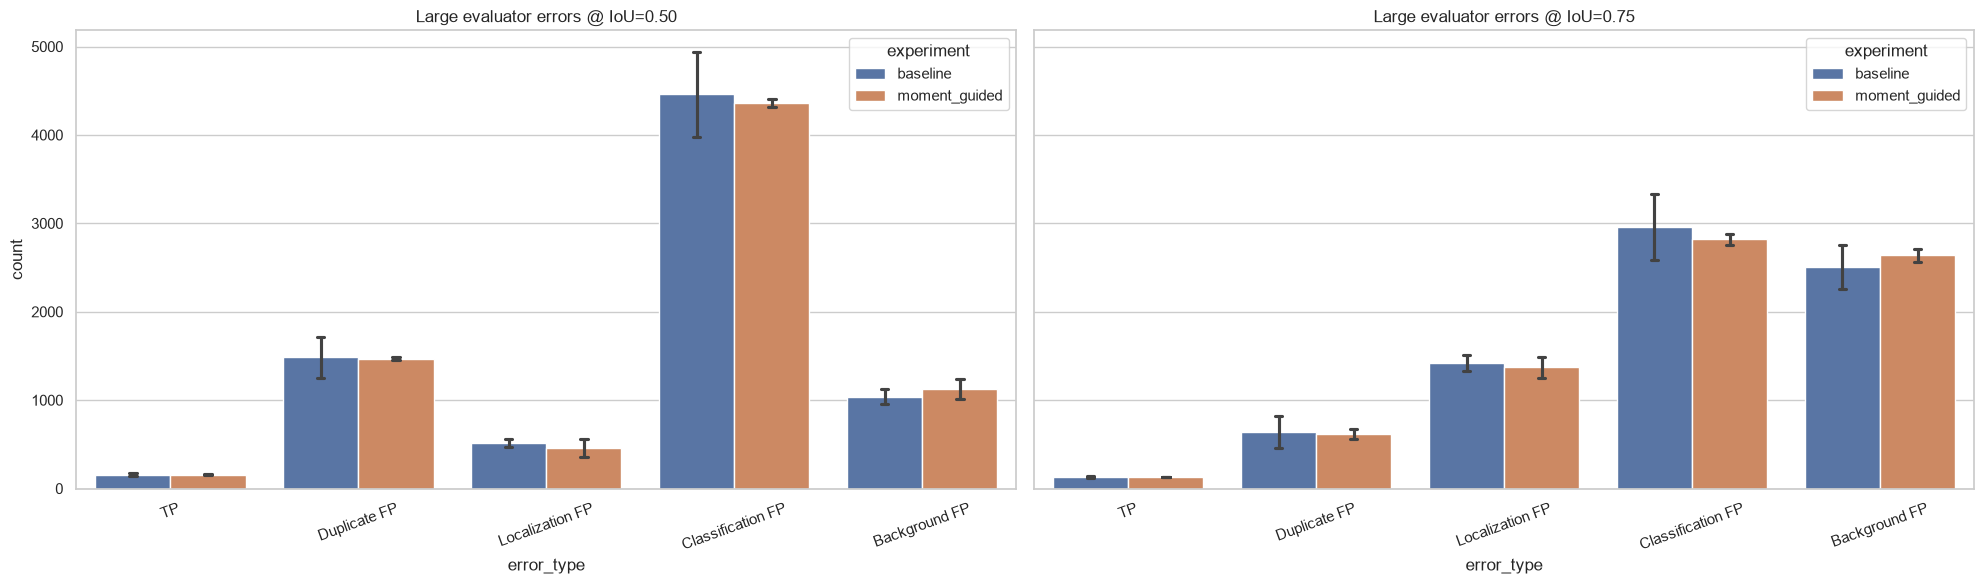

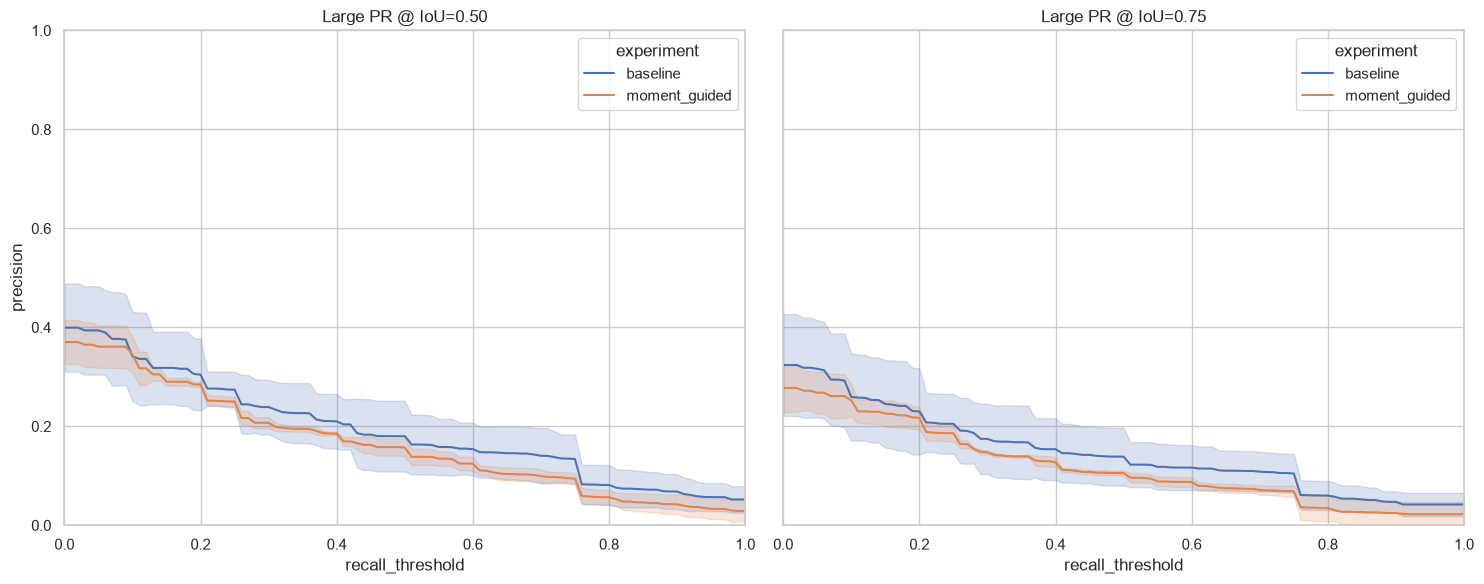

In [11]:
if RUN_LARGE_DECOMPOSITION:
    error_event_df, error_metric_df, pr_df = moment_eval.large_error_decomposition(
        prediction_df, BUNDLE.val_records, iou_thresholds=(0.50, 0.75),
    )
    error_event_df.to_csv(ERROR_EVENT_PATH, index=False)
    error_metric_df.to_csv(ERROR_METRIC_PATH, index=False)
    pr_df.to_csv(PR_PATH, index=False)
else:
    error_event_df = pd.read_csv(ERROR_EVENT_PATH)
    error_metric_df = pd.read_csv(ERROR_METRIC_PATH)
    pr_df = pd.read_csv(PR_PATH)
display(error_metric_df)

COUNT_TYPES = ['TP', 'Duplicate FP', 'Localization FP', 'Classification FP', 'Background FP']
count_plot = error_metric_df.melt(id_vars=['experiment', 'seed', 'iou_threshold'], value_vars=COUNT_TYPES, var_name='error_type', value_name='count')
fig, axes = plt.subplots(1, 2, figsize=(20, 6), sharey=True)
for axis, threshold in zip(axes, [0.50, 0.75]):
    sns.barplot(data=count_plot.query('iou_threshold == @threshold'), x='error_type', y='count', hue='experiment', estimator='mean', errorbar='sd', capsize=.08, ax=axis)
    axis.set_title(f'Large evaluator errors @ IoU={threshold:.2f}')
    axis.tick_params(axis='x', rotation=20)
plt.tight_layout()
fig.savefig(OUT / 'large_error_types.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for axis, threshold in zip(axes, [0.50, 0.75]):
    sns.lineplot(data=pr_df.query('iou_threshold == @threshold'), x='recall_threshold', y='precision', hue='experiment', estimator='mean', errorbar='sd', ax=axis)
    axis.set_title(f'Large PR @ IoU={threshold:.2f}')
    axis.set_xlim(0, 1); axis.set_ylim(0, 1)
plt.tight_layout()
fig.savefig(OUT / 'large_pr_curves.png', dpi=180, bbox_inches='tight')
plt.show()

In [12]:
ERROR_METRICS = moment_eval.ERROR_TYPES + ['Precision_micro', 'Recall_micro', 'AP_L']
baseline_errors = error_metric_df.query("experiment == 'baseline'")[['seed', 'iou_threshold'] + ERROR_METRICS].rename(columns={m: f'baseline_{m}' for m in ERROR_METRICS})
error_delta = error_metric_df.query("experiment == 'moment_guided'").merge(baseline_errors, on=['seed', 'iou_threshold'])
for metric in ERROR_METRICS:
    error_delta[f'delta_{metric}'] = error_delta[metric] - error_delta[f'baseline_{metric}']
for threshold in [0.50, 0.75]:
    table = error_metric_df.query('iou_threshold == @threshold').groupby('experiment')[ERROR_METRICS].mean().T
    table['Delta'] = table['moment_guided'] - table['baseline']
    display(table.style.format({'baseline': '{:.4f}', 'moment_guided': '{:.4f}', 'Delta': '{:+.4f}'}).set_caption(f'Large @ IoU={threshold:.2f}: seed mean'))
display(error_delta[['seed', 'iou_threshold'] + [f'delta_{m}' for m in ERROR_METRICS]].style.format({f'delta_{m}': '{:+.4f}' for m in ERROR_METRICS}))

experiment,baseline,moment_guided,Delta
TP,156.0000,156.0000,+0.0000
Duplicate FP,1484.6667,1470.6667,-14.0000
Localization FP,514.6667,457.3333,-57.3333
Classification FP,4458.6667,4359.3333,-99.3333
Background FP,1040.3333,1127.6667,+87.3333
Missed GT,34.0000,34.0000,+0.0000
Precision_micro,0.0204,0.0206,+0.0002
Recall_micro,0.8211,0.8211,+0.0000
AP_L,0.1931,0.1659,-0.0272


experiment,baseline,moment_guided,Delta
TP,130.6667,130.0000,-0.6667
Duplicate FP,638.6667,618.0000,-20.6667
Localization FP,1421.3333,1370.0000,-51.3333
Classification FP,2962.3333,2818.0000,-144.3333
Background FP,2502.3333,2637.0000,+134.6667
Missed GT,59.3333,60.0000,+0.6667
Precision_micro,0.0171,0.0172,+0.0001
Recall_micro,0.6877,0.6842,-0.0035
AP_L,0.1475,0.1191,-0.0285


,seed,iou_threshold,delta_TP,delta_Duplicate FP,delta_Localization FP,delta_Classification FP,delta_Background FP,delta_Missed GT,delta_Precision_micro,delta_Recall_micro,delta_AP_L
0,42,0.500000,+3.0000,-148.0000,+25.0000,-18.0000,-73.0000,-3.0000,+0.0009,+0.0158,+0.0090
1,42,0.750000,+1.0000,-162.0000,+54.0000,-396.0000,+291.0000,-1.0000,+0.0006,+0.0053,+0.0029
2,43,0.500000,-17.0000,+277.0000,-47.0000,-632.0000,+39.0000,+17.0000,-0.0012,-0.0895,-0.0933
3,43,0.750000,-16.0000,+240.0000,-27.0000,-382.0000,-192.0000,+16.0000,-0.0012,-0.0842,-0.0944
4,44,0.500000,+14.0000,-171.0000,-150.0000,+352.0000,+296.0000,-14.0000,+0.0010,+0.0737,+0.0026
5,44,0.750000,+13.0000,-140.0000,-181.0000,+345.0000,+305.0000,-13.0000,+0.0010,+0.0684,+0.0062


## 9. 자동 요약

아래 값은 결론을 대신하지 않고, seed 일관성과 Large failure type을 빠르게 찾기 위한 요약입니다.

In [13]:
delta_columns = [f'delta_{m}' for m in OVERALL_METRICS]
mean_overall_delta = overall_delta[delta_columns].mean().to_dict()
consistent_overall = {m: bool((overall_delta[f'delta_{m}'] > 0).all()) for m in OVERALL_METRICS}
delta75 = error_delta.query('iou_threshold == 0.75')
failure_means = {m: float(delta75[f'delta_{m}'].mean()) for m in moment_eval.ERROR_TYPES if m != 'TP'}
dominant_failure = max(failure_means, key=failure_means.get)
latency = overall_df.groupby('experiment')['inference_seconds'].mean()
report = {
    'mean_overall_delta': mean_overall_delta,
    'positive_on_all_3_seeds': consistent_overall,
    'mean_mAP_epoch_auc_delta': float(auc_delta['delta_mAP_epoch_auc'].mean()),
    'dominant_large_failure_increase_at_075': dominant_failure if failure_means[dominant_failure] > 0 else None,
    'large_AP75_delta': float(delta75['delta_AP_L'].mean()),
    'inference_seconds_ratio_moment_over_baseline': float(latency['moment_guided'] / latency['baseline']),
    'extra_inference_parameters': 0,
}
print(json.dumps(report, indent=2, ensure_ascii=False))
print('All evaluation artifacts:', OUT)

{
  "mean_overall_delta": {
    "delta_mAP": -0.0025979429483413696,
    "delta_AP50": -0.005657869080702464,
    "delta_AP75": -0.0006299888094266256,
    "delta_AR100": -0.005919118722279866
  },
  "positive_on_all_3_seeds": {
    "mAP": false,
    "AP50": false,
    "AP75": false,
    "AR100": false
  },
  "mean_mAP_epoch_auc_delta": -9.168461630388106e-05,
  "dominant_large_failure_increase_at_075": "Background FP",
  "large_AP75_delta": -0.028467034784803308,
  "inference_seconds_ratio_moment_over_baseline": 0.9403206934509346,
  "extra_inference_parameters": 0
}
All evaluation artifacts: D:\gt-super\outputs\moment_guided_detr\evaluation
